# 6CS012 - Fruit Image Classification
## Part A: CNN from Scratch | Part B: Transfer Learning

In [1]:
# mount google drive
# from google.colab import drive
# drive.mount('/content/drive')

In [2]:
# import all libraries needed
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import random
import time

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

2026-05-09 10:26:58.184905: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778322418.410868     107 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778322418.478335     107 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778322419.013829     107 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778322419.013868     107 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778322419.013871     107 computation_placer.cc:177] computation placer alr

In [3]:
# set the path to dataset in google drive
# train_dir = '/content/drive/MyDrive/AI_ML_Assessment/fruits_dataset/Training'
# test_dir  = '/content/drive/MyDrive/AI_ML_Assessment/fruits_dataset/Test'

# set the path to dataset in kaggle
train_dir = '/kaggle/input/datasets/sandhyashiwakoti/fruits-dataset/fruits_dataset/Training'
test_dir  = '/kaggle/input/datasets/sandhyashiwakoti/fruits-dataset/fruits_dataset/Test'

# image settings
img_size   = (100, 100)
batch_size = 32

# get class names
class_names = sorted(os.listdir(train_dir))
num_classes = len(class_names)
print("Number of classes:", num_classes)
print("Classes:", class_names)

Number of classes: 15
Classes: ['Apricot', 'Avocado', 'Banana', 'Blueberry', 'Guava', 'Kiwi', 'Lychee', 'Mango', 'Orange', 'Peach', 'Pineapple', 'Pomegranate', 'Raspberry', 'Strawberry', 'Watermelon']


## Part A - Section 1: Data Analysis and Visualization

In [4]:
# count images in each class for train and test
train_counts = []
test_counts  = []

for cls in class_names:
    train_counts.append(len(os.listdir(os.path.join(train_dir, cls))))
    test_counts.append(len(os.listdir(os.path.join(test_dir, cls))))

print("Total training images:", sum(train_counts))
print("Total test images:", sum(test_counts))
print("Total images:", sum(train_counts) + sum(test_counts))

Total training images: 7217
Total test images: 2422
Total images: 9639


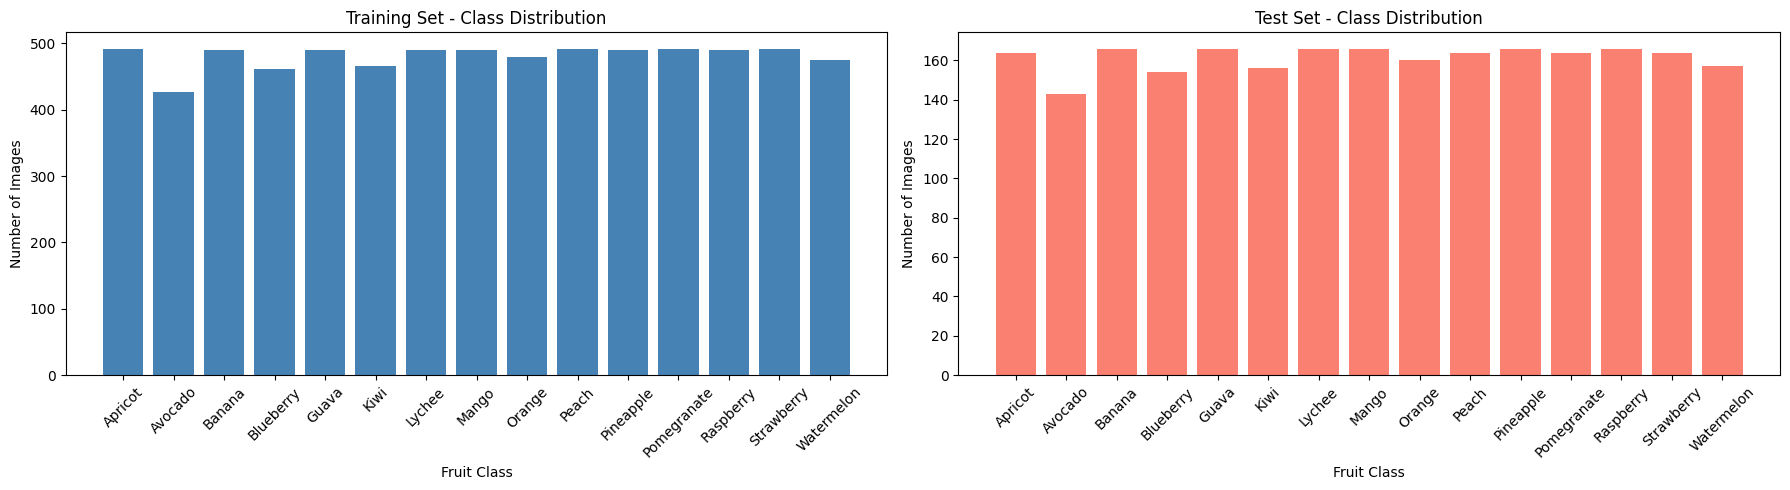

In [5]:
# plot class distribution for train and test
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

axes[0].bar(class_names, train_counts, color='steelblue')
axes[0].set_title('Training Set - Class Distribution')
axes[0].set_xlabel('Fruit Class')
axes[0].set_ylabel('Number of Images')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(class_names, test_counts, color='salmon')
axes[1].set_title('Test Set - Class Distribution')
axes[1].set_xlabel('Fruit Class')
axes[1].set_ylabel('Number of Images')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()

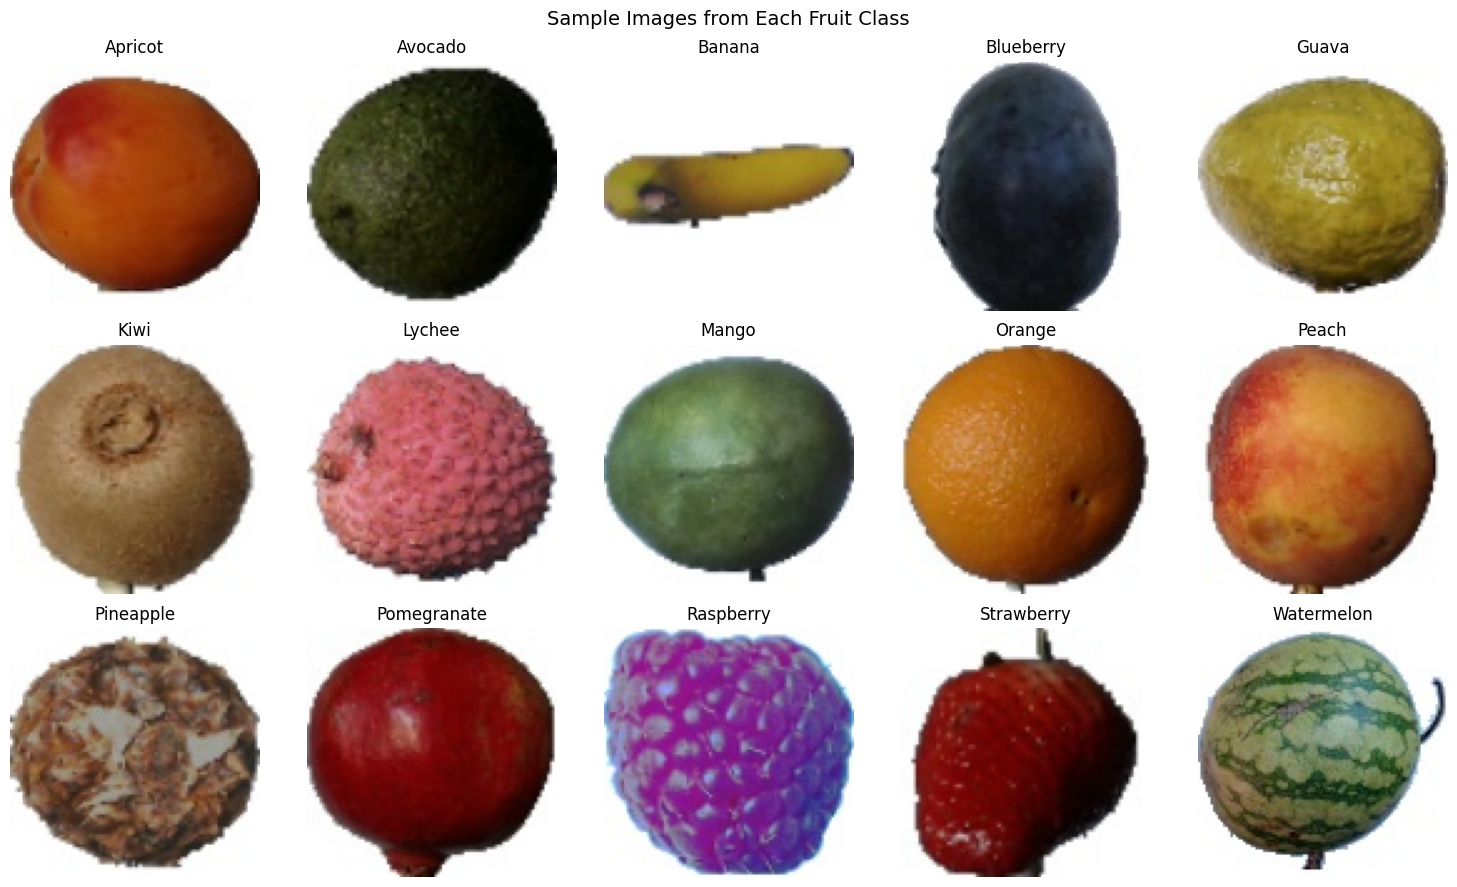

In [6]:
# show one sample image from each class
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
axes = axes.flatten()

for i, cls in enumerate(class_names):
    folder = os.path.join(train_dir, cls)
    img_file = os.listdir(folder)[0]
    img = Image.open(os.path.join(folder, img_file))
    axes[i].imshow(img)
    axes[i].set_title(cls)
    axes[i].axis('off')

plt.suptitle('Sample Images from Each Fruit Class', fontsize=14)
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150)
plt.show()

In [7]:
# check image properties
sample_path = os.path.join(train_dir, class_names[0], os.listdir(os.path.join(train_dir, class_names[0]))[0])
sample_img  = Image.open(sample_path)
sample_arr  = np.array(sample_img)

print("Image size:", sample_img.size)
print("Image mode:", sample_img.mode)
print("Array shape:", sample_arr.shape)
print("Pixel value range:", sample_arr.min(), "to", sample_arr.max())

Image size: (100, 100)
Image mode: RGB
Array shape: (100, 100, 3)
Pixel value range: 0 to 255


## Part A - Section 2: Data Preprocessing and Augmentation

In [8]:
# data generator for training with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.2,
    brightness_range=[0.7, 1.3],
    shear_range=0.2,
    validation_split=0.2
)

# data generator for test - only rescale, no augmentation
test_datagen = ImageDataGenerator(rescale=1./255)

# load training data
train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

# load validation data
val_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

# load test data
test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 5777 images belonging to 15 classes.
Found 1440 images belonging to 15 classes.
Found 2422 images belonging to 15 classes.


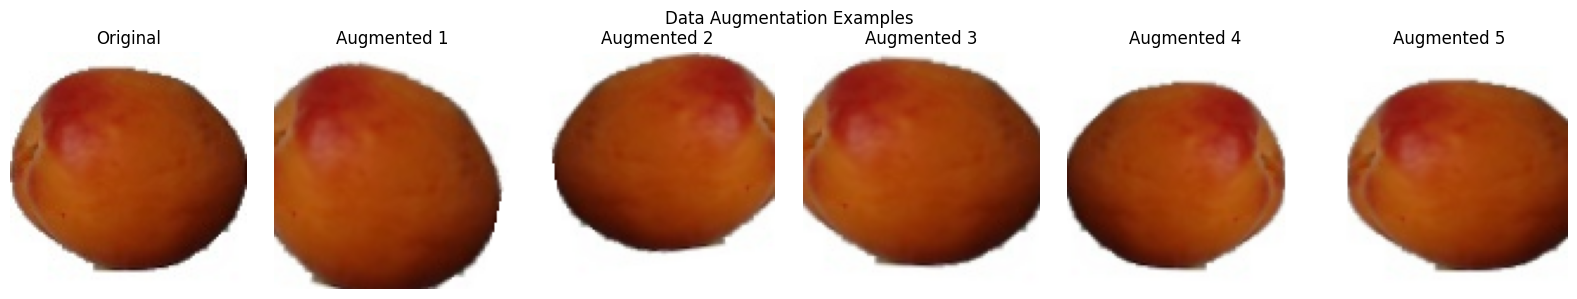

In [9]:
# show some augmented images to see what augmentation looks like
sample_folder = os.path.join(train_dir, class_names[0])
sample_img_path = os.path.join(sample_folder, os.listdir(sample_folder)[0])
sample_img = Image.open(sample_img_path)
sample_arr = np.array(sample_img).reshape((1, 100, 100, 3))

aug_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1, 
    horizontal_flip=True,
    zoom_range=0.1,
    fill_mode='constant', 
    cval=255.0,
    validation_split=0.2
)

fig, axes = plt.subplots(1, 6, figsize=(16, 3))
axes[0].imshow(sample_img)
axes[0].set_title('Original')
axes[0].axis('off')

aug_iter = aug_gen.flow(sample_arr, batch_size=1)
for i in range(1, 6):
    batch = next(aug_iter)
    axes[i].imshow(batch[0])
    axes[i].set_title(f'Augmented {i}')
    axes[i].axis('off')

plt.suptitle('Data Augmentation Examples', fontsize=12)
plt.tight_layout()
plt.savefig('augmented_images.png', dpi=150)
plt.show()

## Part A - Section 3: Baseline CNN Model

In [10]:
# build the baseline cnn model
# 3 conv layers + 3 fully connected layers

baseline_model = models.Sequential([

    # first conv block
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(100, 100, 3)),
    layers.MaxPooling2D((2, 2)),

    # second conv block
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # third conv block
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # flatten before fully connected layers
    layers.Flatten(),

    # first fully connected layer
    layers.Dense(256, activation='relu'),

    # second fully connected layer
    layers.Dense(128, activation='relu'),

    # third fully connected layer 
    layers.Dense(64, activation='relu'),

    # output layer
    layers.Dense(num_classes, activation='softmax')
])

baseline_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1778322455.347558     107 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778322455.353425     107 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 98, 98, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 21, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     3,277,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 15)             │           975 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,412,431 (13.02 MB)

 Trainable params: 3,412,431 (13.02 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# compile the baseline model
baseline_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [12]:
# train the baseline model
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

start_time = time.time()

baseline_history = baseline_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30,
    callbacks=[early_stop]
)

baseline_train_time = time.time() - start_time
print(f"Baseline model training time: {baseline_train_time:.2f} seconds")

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30


I0000 00:00:1778322459.594175     195 service.cc:152] XLA service 0x7cd780006c80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778322459.594224     195 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778322459.594230     195 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778322460.141215     195 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/181 ━━━━━━━━━━━━━━━━━━━━ 18:21 6s/step - accuracy: 0.0625 - loss: 2.7021

I0000 00:00:1778322463.510827     195 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


181/181 ━━━━━━━━━━━━━━━━━━━━ 65s 328ms/step - accuracy: 0.2950 - loss: 2.1569 - val_accuracy: 0.7819 - val_loss: 0.5708
Epoch 2/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 27s 152ms/step - accuracy: 0.8606 - loss: 0.4442 - val_accuracy: 0.9236 - val_loss: 0.2588
Epoch 3/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 28s 152ms/step - accuracy: 0.9533 - loss: 0.1801 - val_accuracy: 0.9424 - val_loss: 0.1848
Epoch 4/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 28s 156ms/step - accuracy: 0.9664 - loss: 0.1129 - val_accuracy: 0.9694 - val_loss: 0.0970
Epoch 5/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 28s 154ms/step - accuracy: 0.9761 - loss: 0.0858 - val_accuracy: 0.9326 - val_loss: 0.1910
Epoch 6/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 28s 154ms/step - accuracy: 0.9720 - loss: 0.0837 - val_accuracy: 0.9722 - val_loss: 0.1028
Epoch 7/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 27s 150ms/step - accuracy: 0.9842 - loss: 0.0521 - val_accuracy: 0.9799 - val_loss: 0.0781
Epoch 8/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 27s 151ms/step - accuracy: 0.9903 - loss: 0.0336 - val

In [13]:
# save baseline model to drive
# baseline_model.save('/content/drive/MyDrive/fruits_dataset/baseline_model.h5')

# save baseline model immediately after training
baseline_model.save('/kaggle/working/baseline_model.h5')

print("Baseline model saved!")



Baseline model saved!


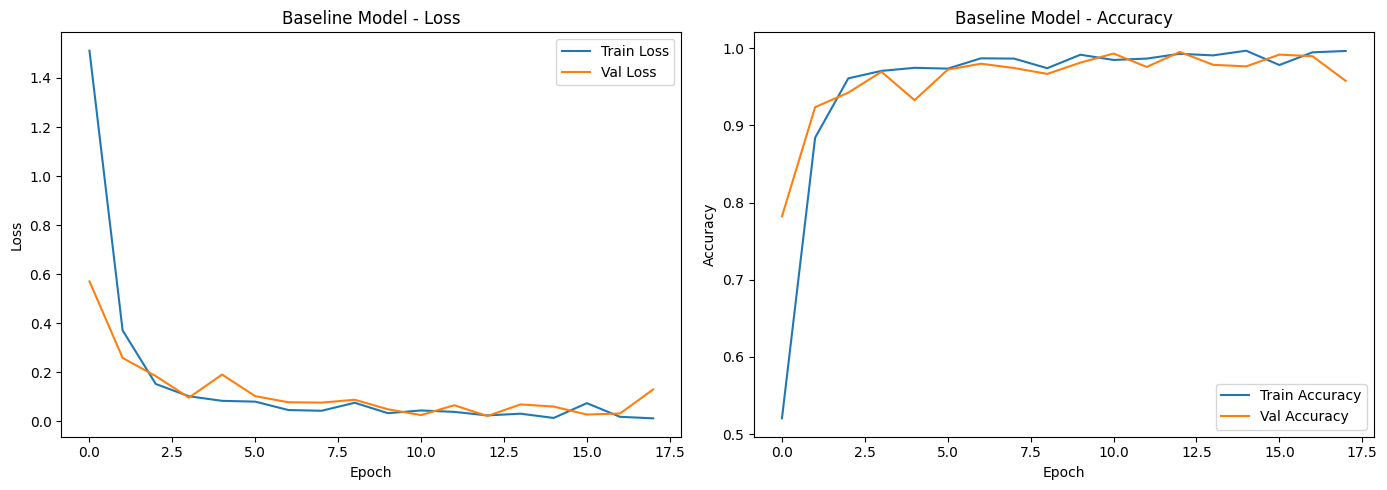

In [14]:
# plot training vs validation loss and accuracy for baseline model
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# loss plot
axes[0].plot(baseline_history.history['loss'], label='Train Loss')
axes[0].plot(baseline_history.history['val_loss'], label='Val Loss')
axes[0].set_title('Baseline Model - Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# accuracy plot
axes[1].plot(baseline_history.history['accuracy'], label='Train Accuracy')
axes[1].plot(baseline_history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('Baseline Model - Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.savefig('baseline_training_curves.png', dpi=150)
plt.show()

In [15]:
# evaluate baseline model on test set
baseline_loss, baseline_acc = baseline_model.evaluate(test_gen)
print(f"Baseline Test Accuracy: {baseline_acc*100:.2f}%")
print(f"Baseline Test Loss: {baseline_loss:.4f}")

76/76 ━━━━━━━━━━━━━━━━━━━━ 17s 220ms/step - accuracy: 0.9911 - loss: 0.0384
Baseline Test Accuracy: 97.89%
Baseline Test Loss: 0.0605


In [16]:
# get predictions and print classification report for baseline
test_gen.reset()
baseline_preds = baseline_model.predict(test_gen)
baseline_pred_labels = np.argmax(baseline_preds, axis=1)
true_labels = test_gen.classes

print("Classification Report - Baseline Model")
print(classification_report(true_labels, baseline_pred_labels, target_names=class_names))

76/76 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step
Classification Report - Baseline Model
              precision    recall  f1-score   support

     Apricot       1.00      1.00      1.00       164
     Avocado       1.00      1.00      1.00       143
      Banana       1.00      1.00      1.00       166
   Blueberry       1.00      1.00      1.00       154
       Guava       1.00      1.00      1.00       166
        Kiwi       1.00      1.00      1.00       156
      Lychee       1.00      1.00      1.00       166
       Mango       1.00      1.00      1.00       166
      Orange       1.00      1.00      1.00       160
       Peach       1.00      0.72      0.84       164
   Pineapple       1.00      1.00      1.00       166
 Pomegranate       0.76      1.00      0.87       164
   Raspberry       1.00      1.00      1.00       166
  Strawberry       1.00      0.97      0.98       164
  Watermelon       1.00      1.00      1.00       157

    accuracy                           0.98      2422
 

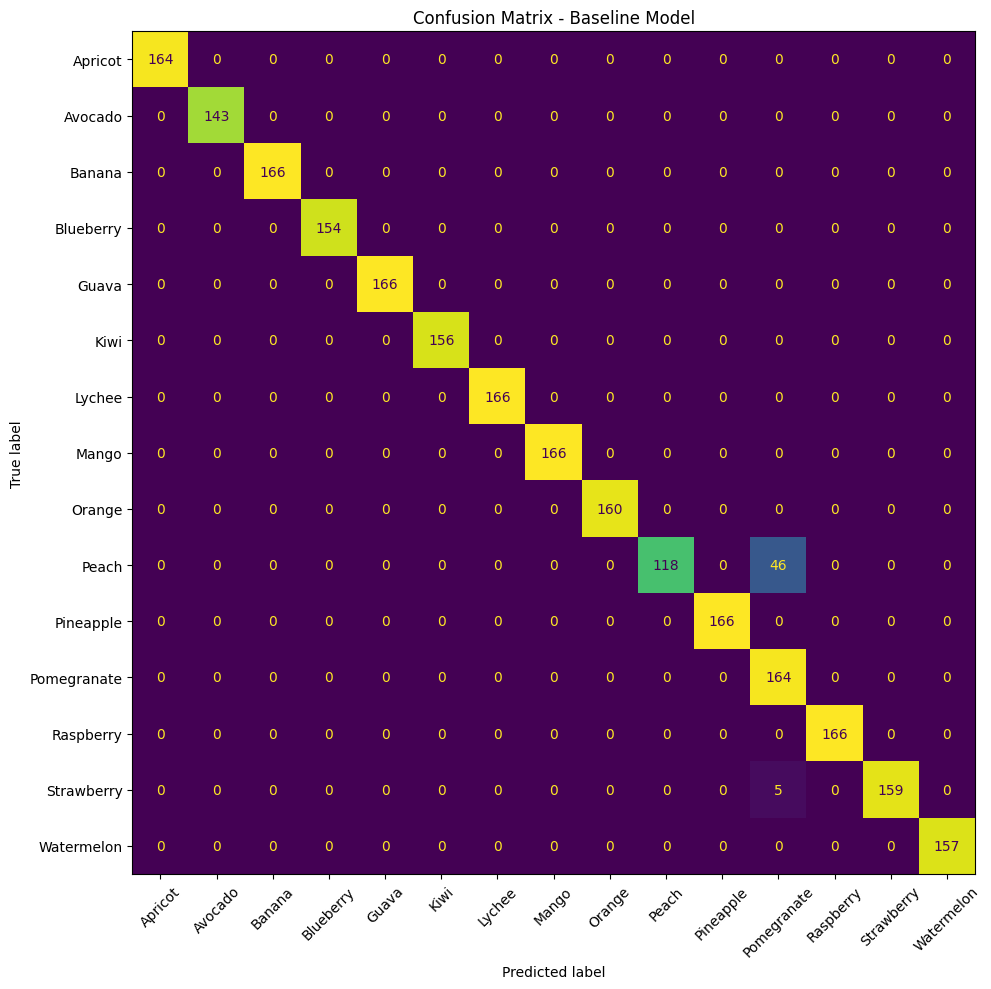

In [17]:
# confusion matrix for baseline model
cm = confusion_matrix(true_labels, baseline_pred_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(12, 10))
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title('Confusion Matrix - Baseline Model')
plt.tight_layout()
plt.savefig('baseline_confusion_matrix.png', dpi=150)
plt.show()

76/76 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step
Total wrong predictions: 51


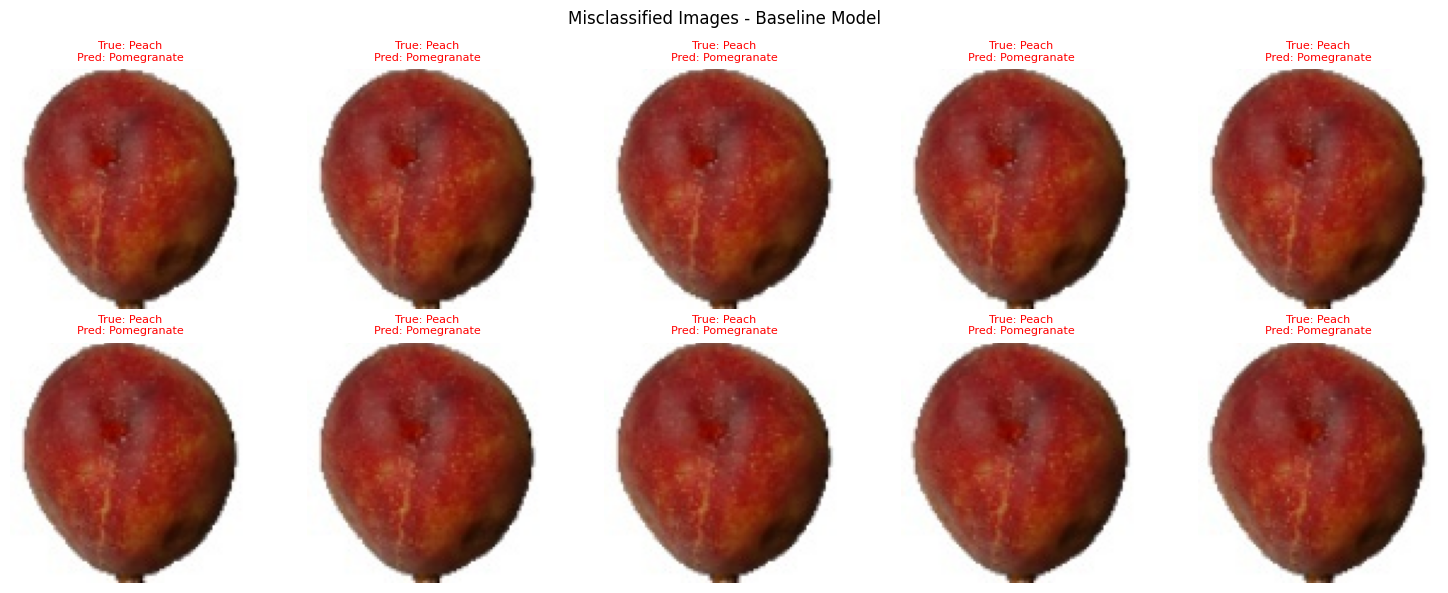

In [18]:
# find misclassified images from baseline model
test_gen.reset()
baseline_preds = baseline_model.predict(test_gen)
baseline_pred_labels = np.argmax(baseline_preds, axis=1)
true_labels = test_gen.classes

# find wrong predictions
wrong_idx = np.where(baseline_pred_labels != true_labels)[0]
print("Total wrong predictions:", len(wrong_idx))

# show only first 10 wrong ones
show_count = min(len(wrong_idx), 10)
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i in range(show_count):
    idx = wrong_idx[i]
    img_path = test_gen.filepaths[idx]
    img = Image.open(img_path)
    axes[i].imshow(img)
    true = class_names[true_labels[idx]]
    pred = class_names[baseline_pred_labels[idx]]
    axes[i].set_title('True: ' + true + '\nPred: ' + pred, color='red', fontsize=8)
    axes[i].axis('off')

plt.suptitle('Misclassified Images - Baseline Model', fontsize=12)
plt.tight_layout()
plt.savefig('misclassified.png', dpi=150)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 794ms/step


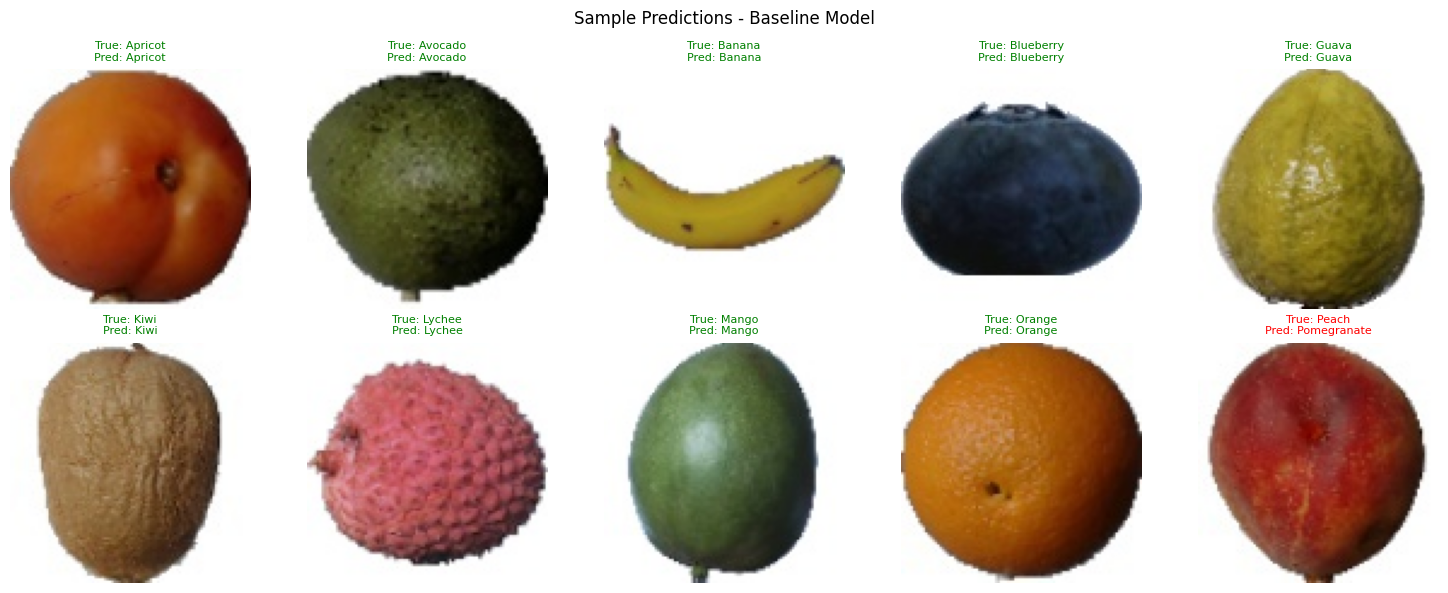

In [19]:
# show sample predictions from different fruit classes
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

test_datagen2 = ImageDataGenerator(rescale=1./255)

selected_images = []
selected_labels = []

# pick one random image from each of 10 different classes
for cls in class_names[:10]:
    folder = os.path.join(test_dir, cls)
    img_file = random.choice(os.listdir(folder))
    img = Image.open(os.path.join(folder, img_file))
    img = img.resize((100, 100))
    img_arr = np.array(img) / 255.0
    selected_images.append(img_arr)
    selected_labels.append(cls)

selected_images = np.array(selected_images)
preds = baseline_model.predict(selected_images)

for i in range(10):
    axes[i].imshow(selected_images[i])
    true_label = selected_labels[i]
    pred_label = class_names[np.argmax(preds[i])]
    color = 'green' if true_label == pred_label else 'red'
    title = 'True: ' + true_label + '\nPred: ' + pred_label
    axes[i].set_title(title, color=color, fontsize=8)
    axes[i].axis('off')

plt.suptitle('Sample Predictions - Baseline Model', fontsize=12)
plt.tight_layout()
plt.savefig('baseline_predictions.png', dpi=150)
plt.show()

## Part A - Section 4: Deeper CNN Model with Regularization

In [20]:
# build deeper cnn model
# double the conv layers compared to baseline + batch norm + dropout

deeper_model = models.Sequential([

    # first conv block
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(100, 100, 3)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.20),

    # second conv block
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.20),

    # third conv block
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.20),

    # flatten and fully connected layers
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

deeper_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 100, 100, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 100, 100, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 100, 100, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 100, 100, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 50, 50, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 50, 50, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 50, 50, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 50, 50, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 25, 25, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 25, 25, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 25, 25, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 25, 25, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │     9,437,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 9,863,727 (37.63 MB)

 Trainable params: 9,861,807 (37.62 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [21]:
# compile deeper model with adam optimizer
deeper_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [22]:
# train the deeper model
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

start_time = time.time()

deeper_history = deeper_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30,
    callbacks=[early_stop]
)

deeper_train_time = time.time() - start_time
print(f"Deeper model training time: {deeper_train_time:.2f} seconds")

Epoch 1/30


2026-05-09 10:37:07.579656: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 10:37:07.720939: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


 26/181 ━━━━━━━━━━━━━━━━━━━━ 19s 124ms/step - accuracy: 0.3897 - loss: 2.0775

2026-05-09 10:37:19.847649: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 10:37:19.987540: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


181/181 ━━━━━━━━━━━━━━━━━━━━ 53s 210ms/step - accuracy: 0.6970 - loss: 0.9675 - val_accuracy: 0.1444 - val_loss: 6.6770
Epoch 2/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 29s 159ms/step - accuracy: 0.9226 - loss: 0.2604 - val_accuracy: 0.2431 - val_loss: 6.1370
Epoch 3/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 29s 158ms/step - accuracy: 0.9398 - loss: 0.1845 - val_accuracy: 0.6840 - val_loss: 2.2677
Epoch 4/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 29s 158ms/step - accuracy: 0.9697 - loss: 0.1073 - val_accuracy: 0.9944 - val_loss: 0.0152
Epoch 5/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 28s 154ms/step - accuracy: 0.9753 - loss: 0.0874 - val_accuracy: 0.8396 - val_loss: 0.6677
Epoch 6/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 28s 154ms/step - accuracy: 0.9521 - loss: 0.1893 - val_accuracy: 0.8993 - val_loss: 0.4981
Epoch 7/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 28s 154ms/step - accuracy: 0.9758 - loss: 0.0700 - val_accuracy: 0.9479 - val_loss: 0.1478
Epoch 8/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 28s 153ms/step - accuracy: 0.9696 - loss: 0.0957 - val

In [23]:
# save deeper model to drive
# deeper_model.save('/content/drive/MyDrive/fruits_dataset/deeper_model.h5')

deeper_model.save('/kaggle/working/deeper_model.h5')

print("Deeper model saved!")

Deeper model saved!


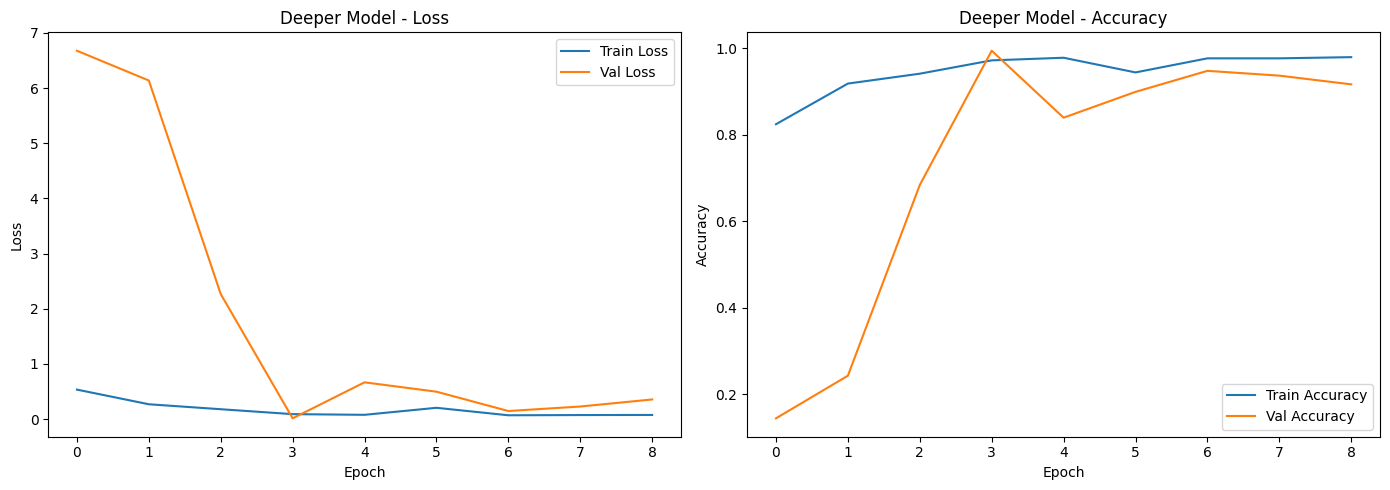

In [24]:
# plot training vs validation curves for deeper model
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(deeper_history.history['loss'], label='Train Loss')
axes[0].plot(deeper_history.history['val_loss'], label='Val Loss')
axes[0].set_title('Deeper Model - Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(deeper_history.history['accuracy'], label='Train Accuracy')
axes[1].plot(deeper_history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('Deeper Model - Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.savefig('deeper_training_curves.png', dpi=150)
plt.show()

In [25]:
# evaluate deeper model on test set
deeper_loss, deeper_acc = deeper_model.evaluate(test_gen)
print(f"Deeper Model Test Accuracy: {deeper_acc*100:.2f}%")
print(f"Deeper Model Test Loss: {deeper_loss:.4f}")

76/76 ━━━━━━━━━━━━━━━━━━━━ 6s 82ms/step - accuracy: 1.0000 - loss: 3.4694e-04
Deeper Model Test Accuracy: 100.00%
Deeper Model Test Loss: 0.0006


In [26]:
# classification report for deeper model
test_gen.reset()
deeper_preds = deeper_model.predict(test_gen)
deeper_pred_labels = np.argmax(deeper_preds, axis=1)

print("Classification Report - Deeper Model")
print(classification_report(true_labels, deeper_pred_labels, target_names=class_names))

76/76 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step
Classification Report - Deeper Model
              precision    recall  f1-score   support

     Apricot       1.00      1.00      1.00       164
     Avocado       1.00      1.00      1.00       143
      Banana       1.00      1.00      1.00       166
   Blueberry       1.00      1.00      1.00       154
       Guava       1.00      1.00      1.00       166
        Kiwi       1.00      1.00      1.00       156
      Lychee       1.00      1.00      1.00       166
       Mango       1.00      1.00      1.00       166
      Orange       1.00      1.00      1.00       160
       Peach       1.00      1.00      1.00       164
   Pineapple       1.00      1.00      1.00       166
 Pomegranate       1.00      1.00      1.00       164
   Raspberry       1.00      1.00      1.00       166
  Strawberry       1.00      1.00      1.00       164
  Watermelon       1.00      1.00      1.00       157

    accuracy                           1.00      2422
   

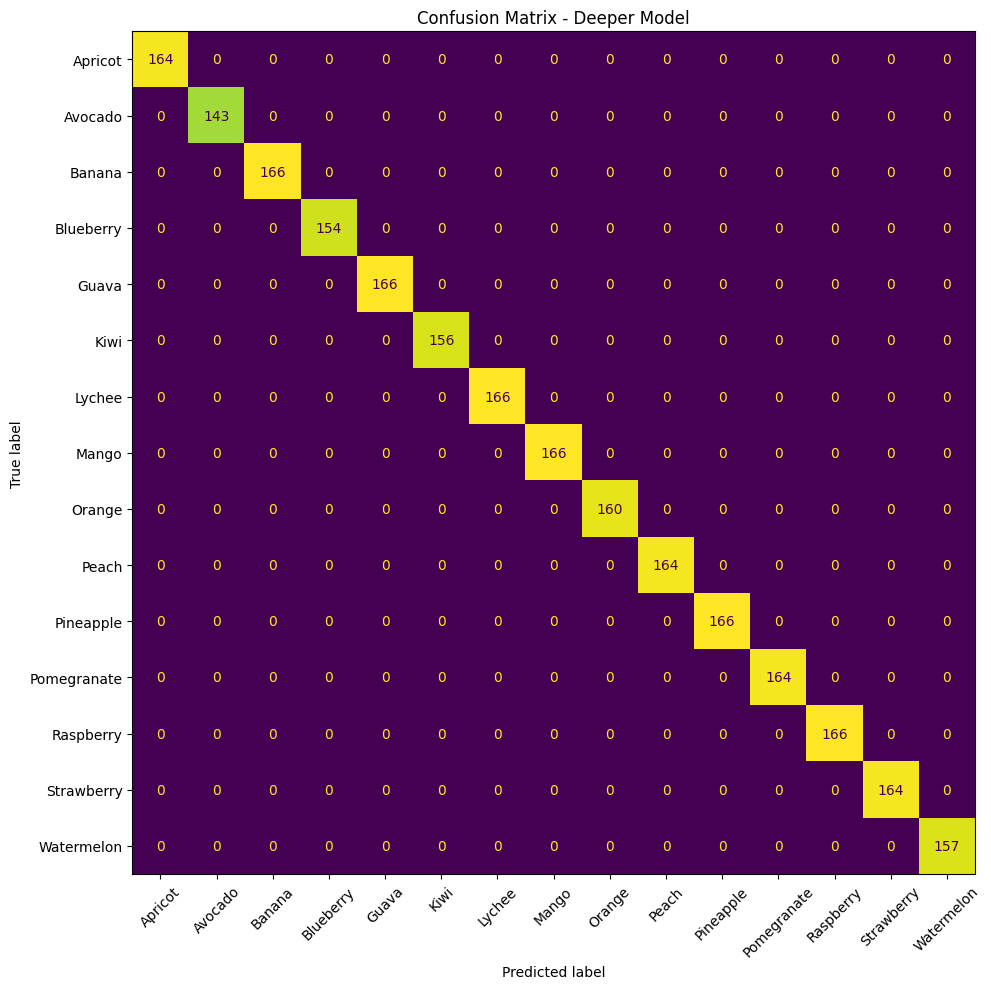

In [27]:
# confusion matrix for deeper model
cm2 = confusion_matrix(true_labels, deeper_pred_labels)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=class_names)
fig, ax = plt.subplots(figsize=(12, 10))
disp2.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title('Confusion Matrix - Deeper Model')
plt.tight_layout()
plt.savefig('deeper_confusion_matrix.png', dpi=150)
plt.show()

In [28]:
# find misclassified images from deeper model
test_gen.reset()
deeper_preds = deeper_model.predict(test_gen)
deeper_pred_labels = np.argmax(deeper_preds, axis=1)

# find wrong predictions
wrong_idx = np.where(deeper_pred_labels != true_labels)[0]
print("Total wrong predictions:", len(wrong_idx))

# show the wrong ones
if len(wrong_idx) > 0:
    # show max 15 wrong images
    show_count = min(len(wrong_idx), 15)
    fig, axes = plt.subplots(1, show_count, figsize=(20, 4))
    if show_count == 1:
        axes = [axes]

    for i in range(show_count):
        idx = wrong_idx[i]
        img_path = test_gen.filepaths[idx]
        img = Image.open(img_path)
        axes[i].imshow(img)
        true = class_names[true_labels[idx]]
        pred = class_names[deeper_pred_labels[idx]]
        axes[i].set_title('True: ' + true + '\nPred: ' + pred, color='red', fontsize=7)
        axes[i].axis('off')

    plt.suptitle('Misclassified Images - Deeper Model', fontsize=12)
    plt.tight_layout()
    plt.savefig('deeper_misclassified.png', dpi=150)
    plt.show()
else:
    print("No wrong predictions!")

76/76 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step
Total wrong predictions: 0
No wrong predictions!


## Part A - Section 5: Comparison - Baseline vs Deeper Model

In [29]:
# compare baseline vs deeper model results
print("Model Comparison")
print("-" * 40)
print(f"Baseline Accuracy : {baseline_acc*100:.2f}%")
print(f"Deeper Accuracy   : {deeper_acc*100:.2f}%")
print(f"Baseline Loss     : {baseline_loss:.4f}")
print(f"Deeper Loss       : {deeper_loss:.4f}")
print(f"Baseline Train Time: {baseline_train_time:.2f} sec")
print(f"Deeper Train Time  : {deeper_train_time:.2f} sec")

Model Comparison
----------------------------------------
Baseline Accuracy : 97.89%
Deeper Accuracy   : 100.00%
Baseline Loss     : 0.0605
Deeper Loss       : 0.0006
Baseline Train Time: 534.24 sec
Deeper Train Time  : 278.66 sec


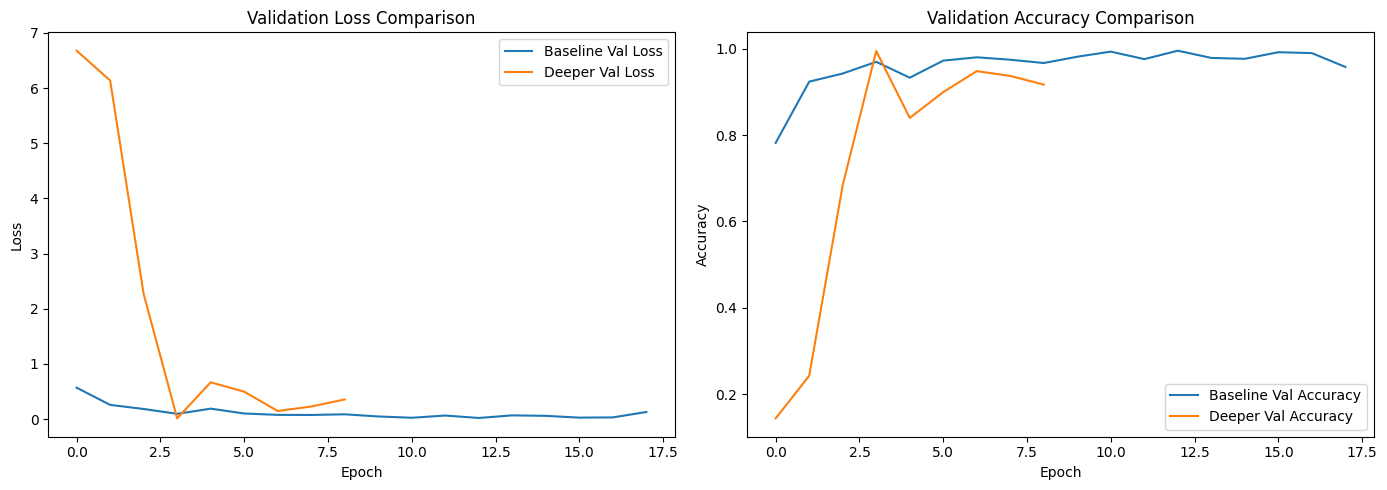

In [30]:
# plot comparison of loss curves baseline vs deeper
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(baseline_history.history['val_loss'], label='Baseline Val Loss')
axes[0].plot(deeper_history.history['val_loss'], label='Deeper Val Loss')
axes[0].set_title('Validation Loss Comparison')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(baseline_history.history['val_accuracy'], label='Baseline Val Accuracy')
axes[1].plot(deeper_history.history['val_accuracy'], label='Deeper Val Accuracy')
axes[1].set_title('Validation Accuracy Comparison')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

## Part A - Section 6: Optimizer Comparison - SGD vs Adam

In [50]:
# train deeper model with SGD optimizer to compare with Adam
deeper_model_sgd = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(100, 100, 3)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.20),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.20),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.20),

    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

# compile with SGD
deeper_model_sgd.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [51]:
# train with sgd
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

train_gen.reset()
val_gen.reset()

sgd_history = deeper_model_sgd.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30,
    callbacks=[early_stop]
)

sgd_loss, sgd_acc = deeper_model_sgd.evaluate(test_gen)
print(f"SGD Test Accuracy: {sgd_acc*100:.2f}%")

Epoch 1/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 49s 224ms/step - accuracy: 0.4883 - loss: 1.6696 - val_accuracy: 0.3604 - val_loss: 4.7847
Epoch 2/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 28s 153ms/step - accuracy: 0.7807 - loss: 0.6360 - val_accuracy: 0.8715 - val_loss: 0.3912
Epoch 3/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 27s 151ms/step - accuracy: 0.9033 - loss: 0.2879 - val_accuracy: 0.7875 - val_loss: 0.7440
Epoch 4/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 27s 150ms/step - accuracy: 0.9006 - loss: 0.3008 - val_accuracy: 0.9410 - val_loss: 0.1613
Epoch 5/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 27s 152ms/step - accuracy: 0.9213 - loss: 0.2423 - val_accuracy: 0.8958 - val_loss: 0.2865
Epoch 6/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 27s 151ms/step - accuracy: 0.9148 - loss: 0.2451 - val_accuracy: 0.9486 - val_loss: 0.1662
Epoch 7/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 27s 151ms/step - accuracy: 0.9431 - loss: 0.1627 - val_accuracy: 0.9701 - val_loss: 0.0759
Epoch 8/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 27s 149ms/step - accuracy: 0.9412 - loss: 0

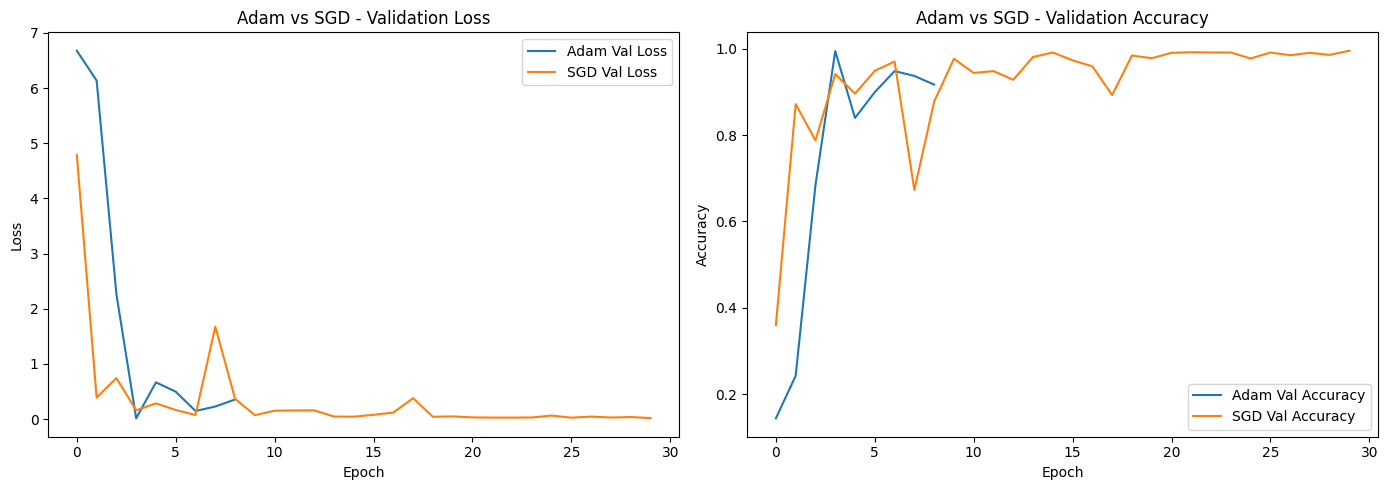

Adam Test Accuracy : 100.00%
SGD Test Accuracy  : 99.26%


In [52]:
# compare adam vs sgd training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(deeper_history.history['val_loss'], label='Adam Val Loss')
axes[0].plot(sgd_history.history['val_loss'], label='SGD Val Loss')
axes[0].set_title('Adam vs SGD - Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(deeper_history.history['val_accuracy'], label='Adam Val Accuracy')
axes[1].plot(sgd_history.history['val_accuracy'], label='SGD Val Accuracy')
axes[1].set_title('Adam vs SGD - Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.savefig('optimizer_comparison.png', dpi=150)
plt.show()

print(f"Adam Test Accuracy : {deeper_acc*100:.2f}%")
print(f"SGD Test Accuracy  : {sgd_acc*100:.2f}%")

In [34]:
deeper_model_sgd.save('/kaggle/working/sgd_model.h5')
print("SGD model saved!")

SGD model saved!


## Part A - Section 7: Ablation Study - Remove Dropout

In [35]:
# ablation study - build deeper model without dropout to see its effect
model_no_dropout = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(100, 100, 3)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model_no_dropout.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [36]:
# train model without dropout
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

train_gen.reset()
val_gen.reset()

ablation_history = model_no_dropout.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30,
    callbacks=[early_stop]
)

ablation_loss, ablation_acc = model_no_dropout.evaluate(test_gen)
print(f"No Dropout Test Accuracy: {ablation_acc*100:.2f}%")

Epoch 1/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 41s 181ms/step - accuracy: 0.7785 - loss: 0.7244 - val_accuracy: 0.0938 - val_loss: 11.6148
Epoch 2/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 28s 157ms/step - accuracy: 0.9078 - loss: 0.2685 - val_accuracy: 0.1944 - val_loss: 7.3867
Epoch 3/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 29s 157ms/step - accuracy: 0.9606 - loss: 0.1132 - val_accuracy: 0.5472 - val_loss: 3.2843
Epoch 4/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 29s 157ms/step - accuracy: 0.9504 - loss: 0.1550 - val_accuracy: 0.8306 - val_loss: 0.6718
Epoch 5/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 29s 159ms/step - accuracy: 0.9754 - loss: 0.0676 - val_accuracy: 0.9854 - val_loss: 0.0374
Epoch 6/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 29s 161ms/step - accuracy: 0.9753 - loss: 0.0873 - val_accuracy: 0.9153 - val_loss: 0.3669
Epoch 7/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 29s 160ms/step - accuracy: 0.9823 - loss: 0.0487 - val_accuracy: 0.9722 - val_loss: 0.1202
Epoch 8/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 30s 164ms/step - accuracy: 0.9816 - loss: 

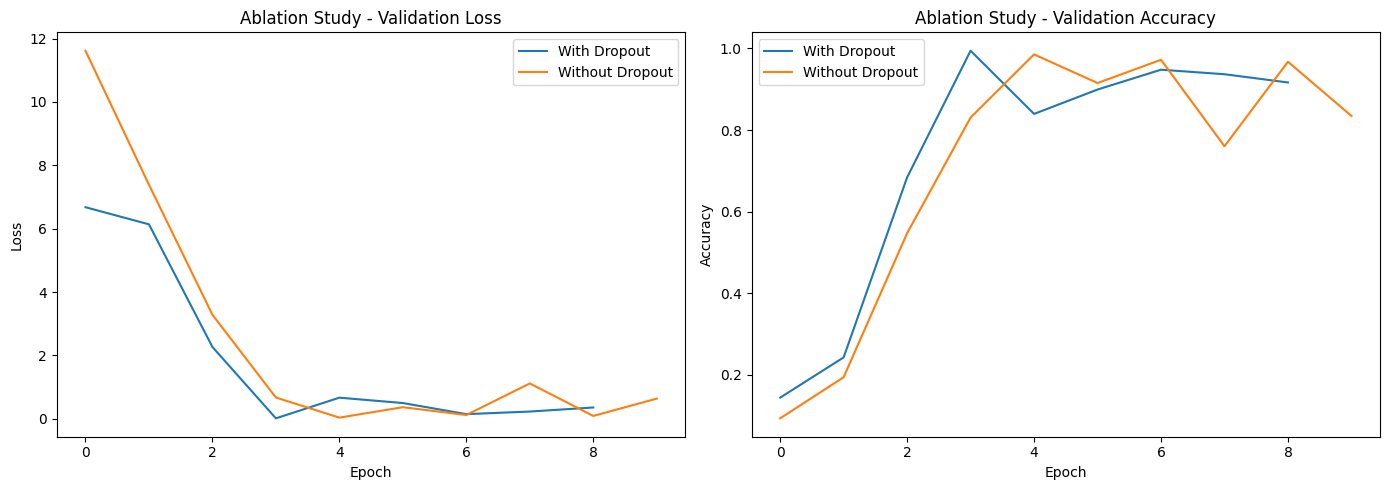

With Dropout Accuracy    : 100.00%
Without Dropout Accuracy : 96.78%


In [37]:
# compare with dropout vs without dropout
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(deeper_history.history['val_loss'], label='With Dropout')
axes[0].plot(ablation_history.history['val_loss'], label='Without Dropout')
axes[0].set_title('Ablation Study - Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(deeper_history.history['val_accuracy'], label='With Dropout')
axes[1].plot(ablation_history.history['val_accuracy'], label='Without Dropout')
axes[1].set_title('Ablation Study - Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.savefig('ablation_study.png', dpi=150)
plt.show()

print(f"With Dropout Accuracy    : {deeper_acc*100:.2f}%")
print(f"Without Dropout Accuracy : {ablation_acc*100:.2f}%")

## Part B - Transfer Learning with Pretrained Model

In [38]:
# load pretrained MobileNetV2 - good choice for 100x100 images
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model

# load mobilenetv2 without the top classification layer
base_model = MobileNetV2(
    input_shape=(100, 100, 3),
    include_top=False,
    weights='imagenet'
)

# freeze the base model first - feature extraction only
base_model.trainable = False

print("Base model loaded")
print("Total layers in base model:", len(base_model.layers))

/tmp/ipykernel_107/1982189698.py:6: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Base model loaded
Total layers in base model: 154


In [39]:
# add custom classification layers on top of mobilenetv2
inputs = keras.Input(shape=(100, 100, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

transfer_model = Model(inputs, outputs)
transfer_model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 15)             │         3,855 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,589,775 (9.88 MB)

 Trainable params: 331,791 (1.27 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [40]:
# compile transfer model for feature extraction phase
transfer_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [41]:
# phase 1 - feature extraction - train only top layers
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

train_gen.reset()
val_gen.reset()

print("Phase 1: Feature Extraction")
feature_history = transfer_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    callbacks=[early_stop]
)

Phase 1: Feature Extraction
Epoch 1/15


2026-05-09 10:57:29.851542: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 10:57:29.995227: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 10:57:30.131761: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


128/181 ━━━━━━━━━━━━━━━━━━━━ 6s 127ms/step - accuracy: 0.7473 - loss: 0.9053

2026-05-09 10:57:56.482543: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 10:57:56.619460: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


181/181 ━━━━━━━━━━━━━━━━━━━━ 58s 235ms/step - accuracy: 0.7953 - loss: 0.7283 - val_accuracy: 0.9944 - val_loss: 0.0187
Epoch 2/15
181/181 ━━━━━━━━━━━━━━━━━━━━ 27s 151ms/step - accuracy: 0.9827 - loss: 0.0595 - val_accuracy: 0.9889 - val_loss: 0.0251
Epoch 3/15
181/181 ━━━━━━━━━━━━━━━━━━━━ 32s 175ms/step - accuracy: 0.9843 - loss: 0.0460 - val_accuracy: 0.9910 - val_loss: 0.0242
Epoch 4/15
181/181 ━━━━━━━━━━━━━━━━━━━━ 28s 157ms/step - accuracy: 0.9915 - loss: 0.0233 - val_accuracy: 0.9965 - val_loss: 0.0125
Epoch 5/15
181/181 ━━━━━━━━━━━━━━━━━━━━ 28s 156ms/step - accuracy: 0.9885 - loss: 0.0377 - val_accuracy: 0.9958 - val_loss: 0.0122
Epoch 6/15
181/181 ━━━━━━━━━━━━━━━━━━━━ 28s 154ms/step - accuracy: 0.9949 - loss: 0.0186 - val_accuracy: 0.9917 - val_loss: 0.0247
Epoch 7/15
181/181 ━━━━━━━━━━━━━━━━━━━━ 27s 151ms/step - accuracy: 0.9899 - loss: 0.0276 - val_accuracy: 0.9875 - val_loss: 0.0305
Epoch 8/15
181/181 ━━━━━━━━━━━━━━━━━━━━ 27s 151ms/step - accuracy: 0.9906 - loss: 0.0289 - val

In [42]:
# phase 2 - fine tuning - unfreeze last 30 layers of base model
base_model.trainable = True

# only unfreeze last 30 layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

# recompile with lower learning rate for fine tuning
transfer_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Phase 2: Fine Tuning")
print("Trainable layers:", sum([1 for l in transfer_model.layers if l.trainable]))

train_gen.reset()
val_gen.reset()

finetune_history = transfer_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    callbacks=[early_stop]
)

Phase 2: Fine Tuning
Trainable layers: 6
Epoch 1/15
181/181 ━━━━━━━━━━━━━━━━━━━━ 53s 209ms/step - accuracy: 0.9569 - loss: 0.1676 - val_accuracy: 0.9431 - val_loss: 0.7176
Epoch 2/15
181/181 ━━━━━━━━━━━━━━━━━━━━ 28s 153ms/step - accuracy: 0.9904 - loss: 0.0315 - val_accuracy: 0.9285 - val_loss: 0.6912
Epoch 3/15
181/181 ━━━━━━━━━━━━━━━━━━━━ 28s 152ms/step - accuracy: 0.9944 - loss: 0.0173 - val_accuracy: 0.9708 - val_loss: 0.1812
Epoch 4/15
181/181 ━━━━━━━━━━━━━━━━━━━━ 28s 153ms/step - accuracy: 0.9930 - loss: 0.0185 - val_accuracy: 0.9715 - val_loss: 0.1765
Epoch 5/15
181/181 ━━━━━━━━━━━━━━━━━━━━ 28s 152ms/step - accuracy: 0.9957 - loss: 0.0121 - val_accuracy: 0.9833 - val_loss: 0.1122
Epoch 6/15
181/181 ━━━━━━━━━━━━━━━━━━━━ 28s 153ms/step - accuracy: 0.9954 - loss: 0.0183 - val_accuracy: 0.9549 - val_loss: 0.4048
Epoch 7/15
181/181 ━━━━━━━━━━━━━━━━━━━━ 27s 152ms/step - accuracy: 0.9958 - loss: 0.0139 - val_accuracy: 0.9771 - val_loss: 0.1519
Epoch 8/15
181/181 ━━━━━━━━━━━━━━━━━━━━ 28

In [43]:
transfer_model.save('/kaggle/working/transfer_model.h5')
print("Transfer model saved!")

Transfer model saved!


In [44]:
# evaluate transfer learning model
test_gen.reset()
transfer_loss, transfer_acc = transfer_model.evaluate(test_gen)
print(f"Transfer Learning Test Accuracy: {transfer_acc*100:.2f}%")
print(f"Transfer Learning Test Loss: {transfer_loss:.4f}")

75/76 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.9989 - loss: 0.0041

2026-05-09 11:11:53.410745: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 11:11:53.546823: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


76/76 ━━━━━━━━━━━━━━━━━━━━ 14s 191ms/step - accuracy: 0.9988 - loss: 0.0043
Transfer Learning Test Accuracy: 99.63%
Transfer Learning Test Loss: 0.0140


In [45]:
# classification report for transfer model
test_gen.reset()
transfer_preds = transfer_model.predict(test_gen)
transfer_pred_labels = np.argmax(transfer_preds, axis=1)

print("Classification Report - Transfer Learning Model")
print(classification_report(true_labels, transfer_pred_labels, target_names=class_names))

76/76 ━━━━━━━━━━━━━━━━━━━━ 10s 82ms/step
Classification Report - Transfer Learning Model
              precision    recall  f1-score   support

     Apricot       1.00      1.00      1.00       164
     Avocado       1.00      1.00      1.00       143
      Banana       1.00      1.00      1.00       166
   Blueberry       1.00      1.00      1.00       154
       Guava       1.00      1.00      1.00       166
        Kiwi       1.00      1.00      1.00       156
      Lychee       1.00      1.00      1.00       166
       Mango       1.00      1.00      1.00       166
      Orange       1.00      1.00      1.00       160
       Peach       0.95      1.00      0.97       164
   Pineapple       1.00      1.00      1.00       166
 Pomegranate       1.00      0.95      0.97       164
   Raspberry       1.00      1.00      1.00       166
  Strawberry       1.00      1.00      1.00       164
  Watermelon       1.00      1.00      1.00       157

    accuracy                           1.00  

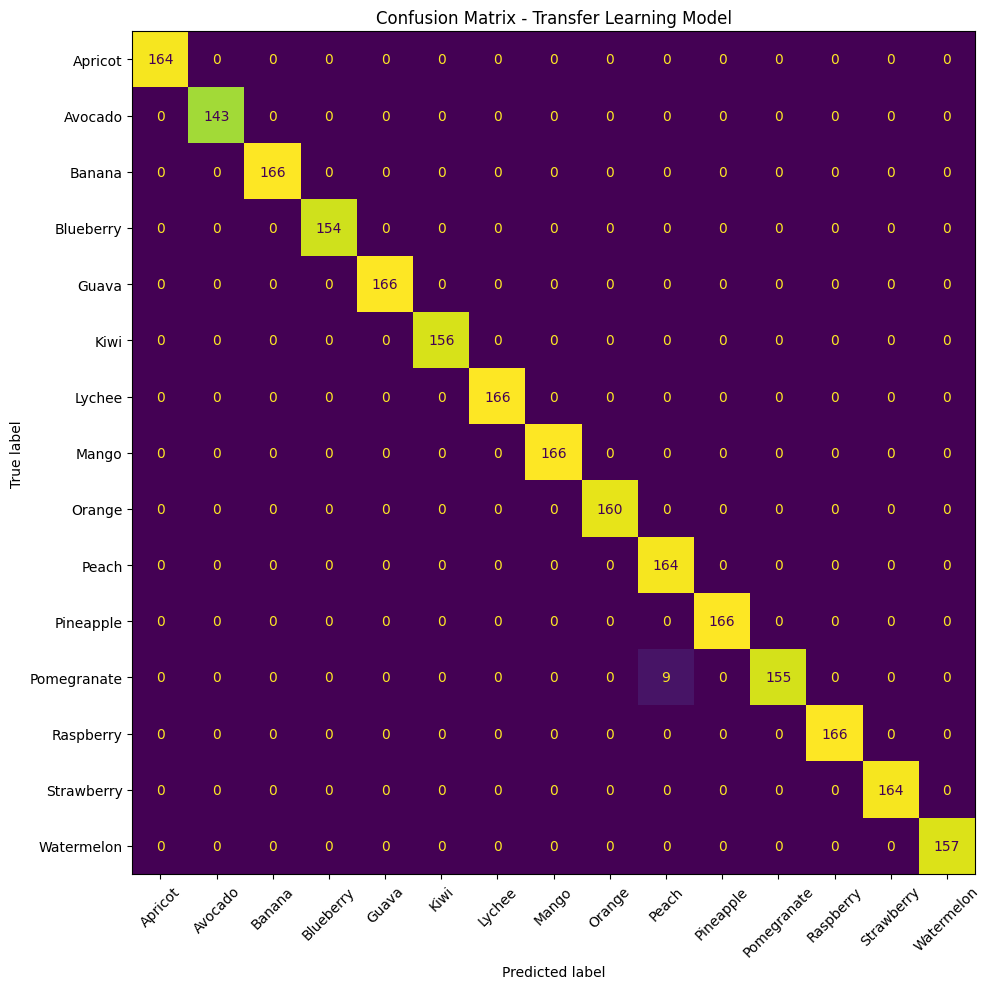

In [46]:
# confusion matrix for transfer learning model
cm3 = confusion_matrix(true_labels, transfer_pred_labels)
disp3 = ConfusionMatrixDisplay(confusion_matrix=cm3, display_labels=class_names)
fig, ax = plt.subplots(figsize=(12, 10))
disp3.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title('Confusion Matrix - Transfer Learning Model')
plt.tight_layout()
plt.savefig('transfer_confusion_matrix.png', dpi=150)
plt.show()

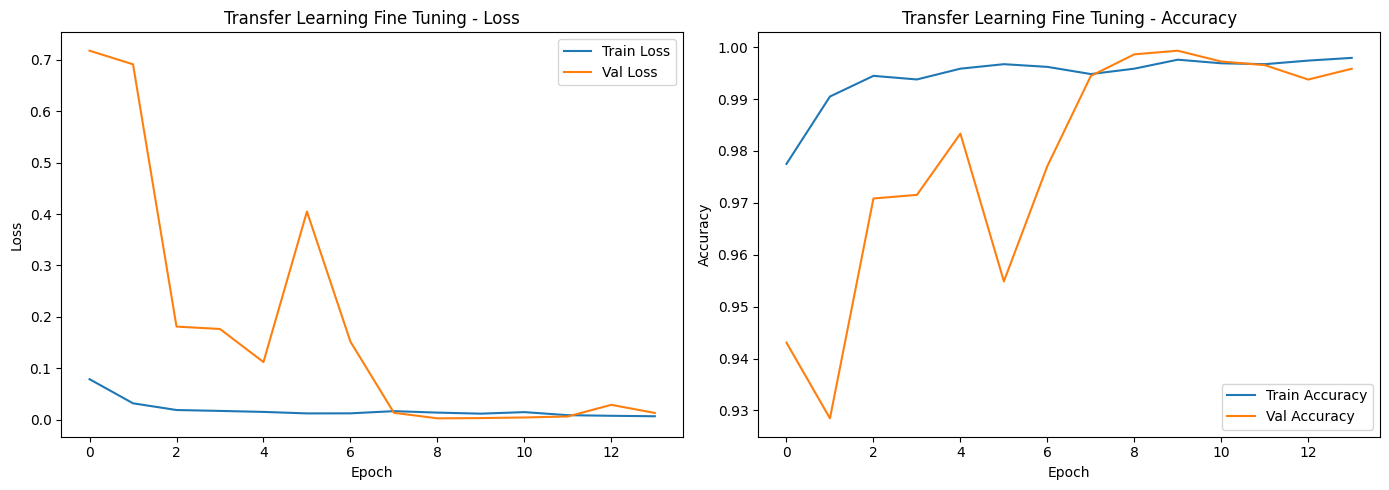

In [47]:
# plot fine tuning training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(finetune_history.history['loss'], label='Train Loss')
axes[0].plot(finetune_history.history['val_loss'], label='Val Loss')
axes[0].set_title('Transfer Learning Fine Tuning - Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(finetune_history.history['accuracy'], label='Train Accuracy')
axes[1].plot(finetune_history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('Transfer Learning Fine Tuning - Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.savefig('transfer_training_curves.png', dpi=150)
plt.show()

In [53]:
# final comparison of all models
print("Final Model Comparison:")
print("--------------------------")
print(f"Baseline CNN Accuracy       : {baseline_acc*100:.2f}%")
print(f"Deeper CNN (Adam) Accuracy  : {deeper_acc*100:.2f}%")
print(f"Deeper CNN (SGD) Accuracy   : {sgd_acc*100:.2f}%")
print(f"No Dropout Accuracy         : {ablation_acc*100:.2f}%")
print(f"Transfer Learning (MobileNetV2) Accuracy  : {transfer_acc*100:.2f}%")

Final Model Comparison:
--------------------------
Baseline CNN Accuracy       : 97.89%
Deeper CNN (Adam) Accuracy  : 100.00%
Deeper CNN (SGD) Accuracy   : 99.26%
No Dropout Accuracy         : 96.78%
Transfer Learning (MobileNetV2) Accuracy  : 99.63%


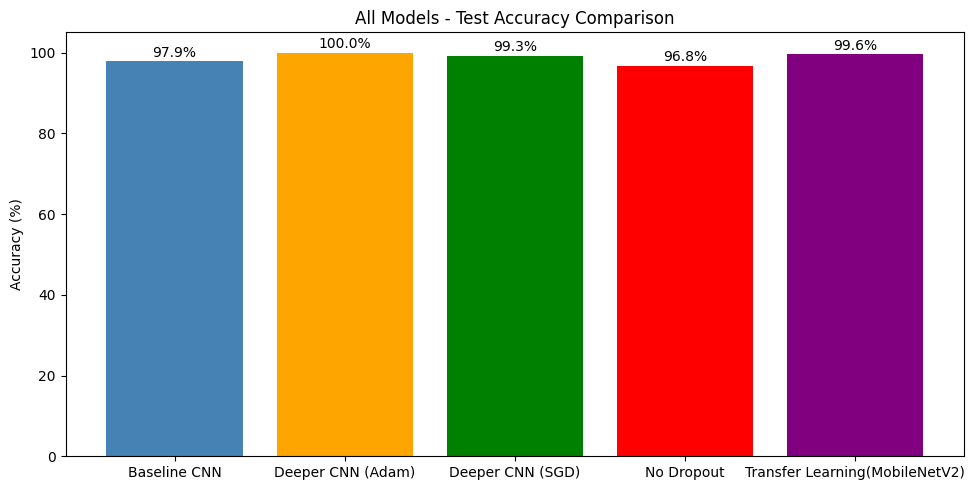

In [54]:
# bar chart comparing all models
model_names = ['Baseline CNN', 'Deeper CNN (Adam)', 'Deeper CNN (SGD)', 'No Dropout', 'Transfer Learning(MobileNetV2)']
accuracies   = [baseline_acc, deeper_acc, sgd_acc, ablation_acc, transfer_acc]

plt.figure(figsize=(10, 5))
bars = plt.bar(model_names, [a*100 for a in accuracies], color=['steelblue','orange','green','red','purple'])
plt.title('All Models - Test Accuracy Comparison')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 105)
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{acc*100:.1f}%', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('final_comparison.png', dpi=150)
plt.show()